# Death Criterion

The goal is of this notebook is to determine the end of life of a worm based solely on its coordinates and the speed data. 


## Speed based criterion

We started by looking at the speed statistics of the worms and plotting them across time. The goal was to find first an **active** block followed by a linearly **decreasing** block and finally a very **low speeds plateau** at the end of life. This shape would have allowed us to determine the end of life by looking at the point where the speed reached the plateau.

However, we did not find such a clear shape in the data. The speed curves were very noisy and did not show a clear decreasing trend followed by a plateau. 

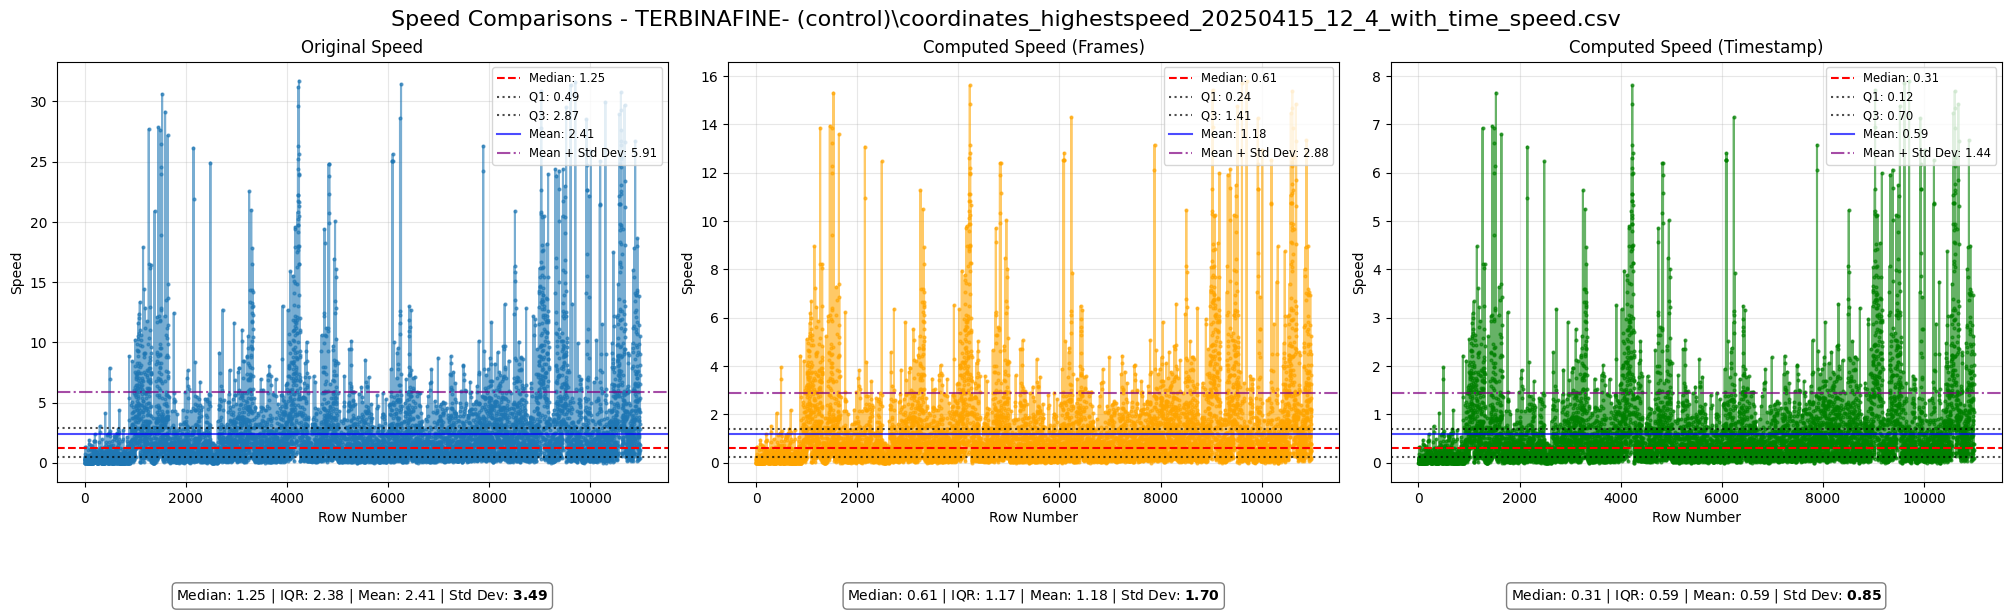

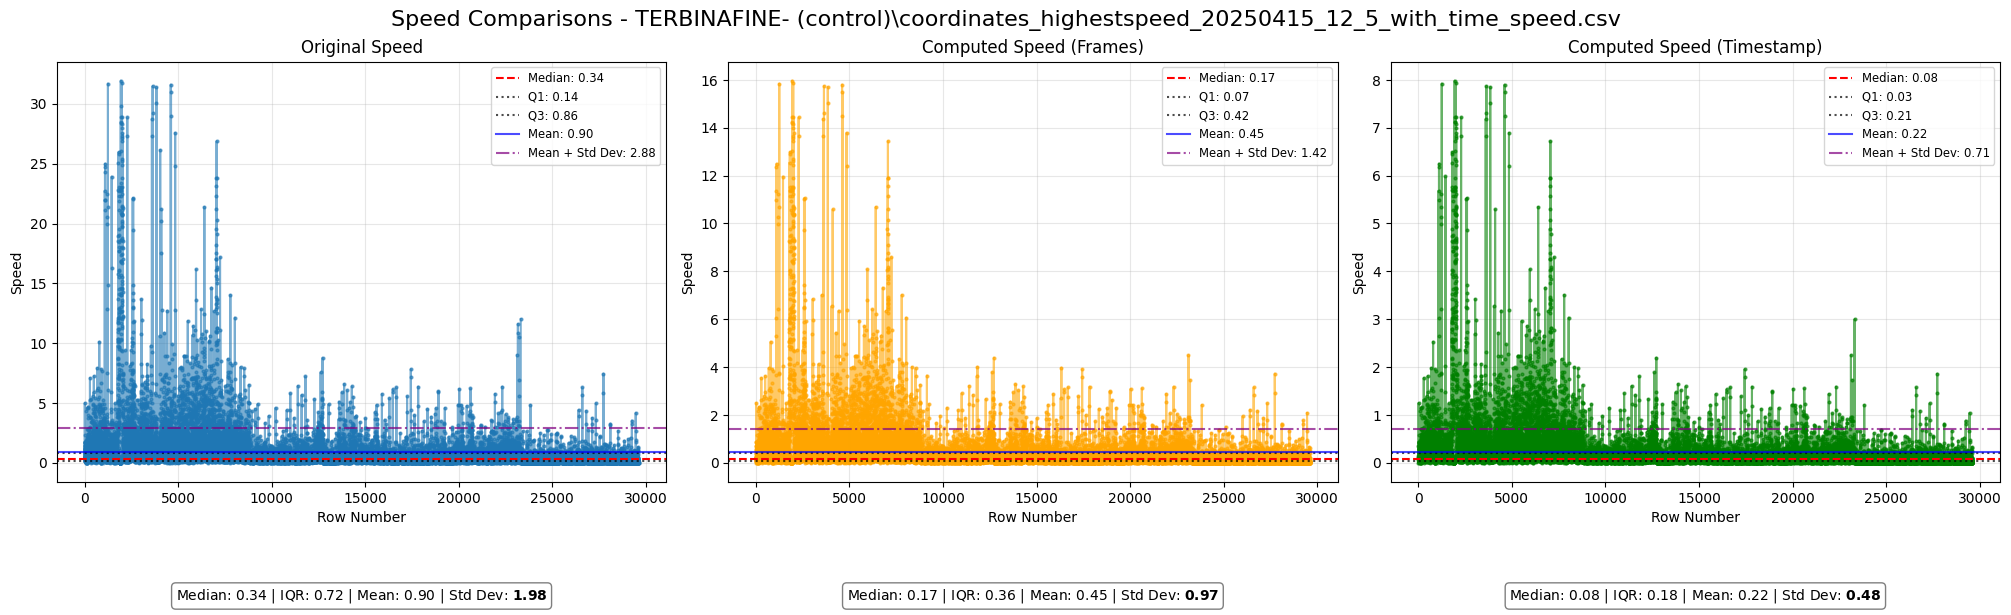

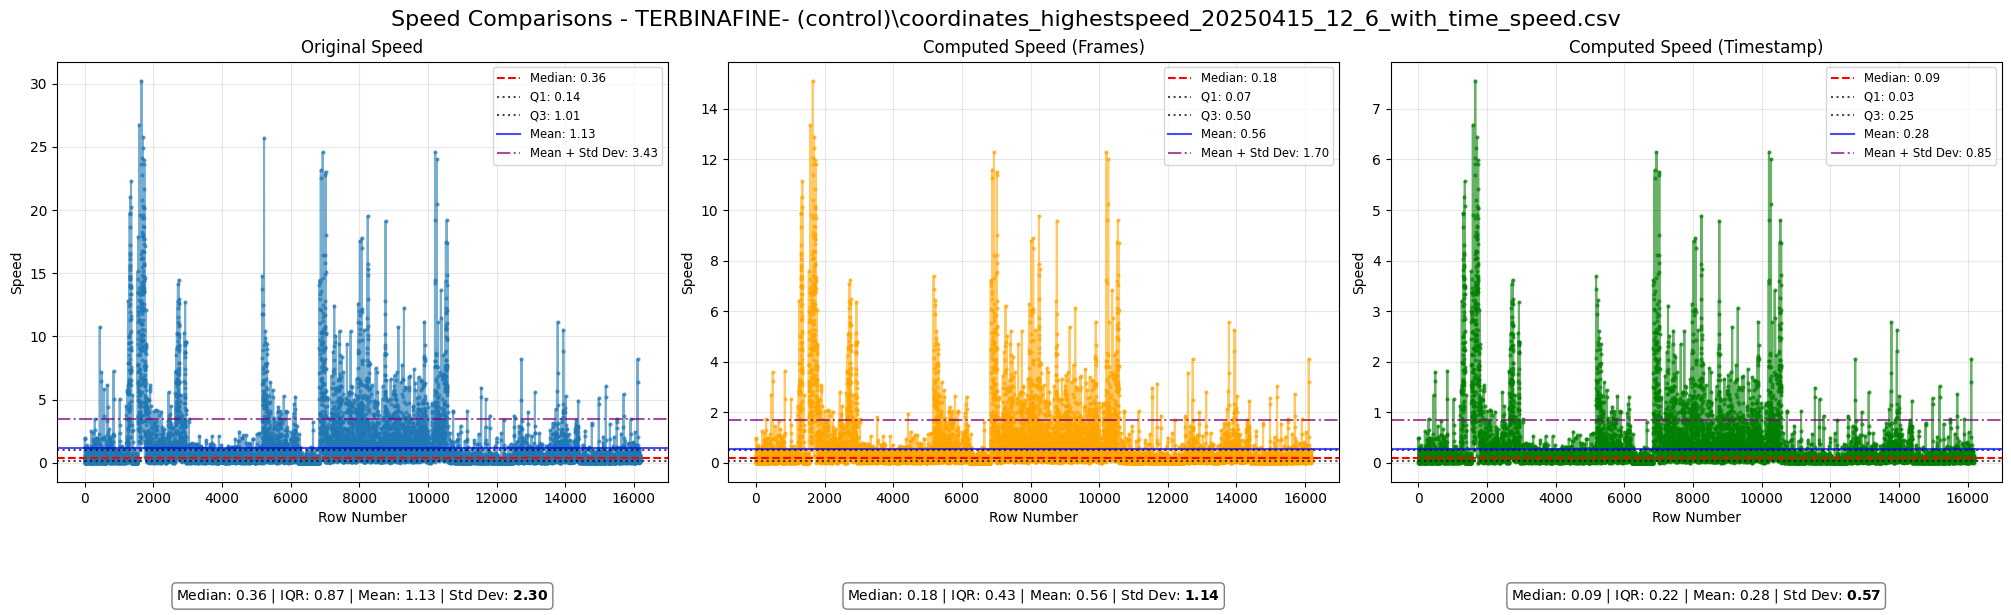

In [6]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.plot_utils.criterion import *

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

preprocessed_folder = '../preprocessed_data'

files = []
for subfolder in os.listdir(preprocessed_folder):
    subfolder_path = os.path.join(preprocessed_folder, subfolder)
    if os.path.isdir(subfolder_path):
        files.extend([os.path.join(subfolder, f) for f in os.listdir(subfolder_path) if f.endswith('.csv')])

# Plot comparisons for a few examples
for file in sorted(files)[-3:]: 
    file_path = os.path.join(preprocessed_folder, file)
    df = pd.read_csv(file_path)
    plot_speed_comparison(df, file)

## Radius based criterion

As the speed criteria was not sufficient, we looked if the worm staid in a radius around its current position for an extended period. This metric should be a better indicator of the worm becoming static (dead or dying). 

We use the `compute_total_smooth_cumulative_distance` function which:
1. Calculates the distance from a point to all future points (periodically) in the dataset.
2. Smooths the results using a sliding window to reduce noise.
3. Maps distances to colors to visually identify the "static" phase (red/orange).

The parameters are compute every 200 frames for a cumulative distance of 200 frames, and a sliding window of 15 frames.

Analyzing: TERBINAFINE+\coordinates_highestspeed_20240827_11_4_with_time_speed.csv


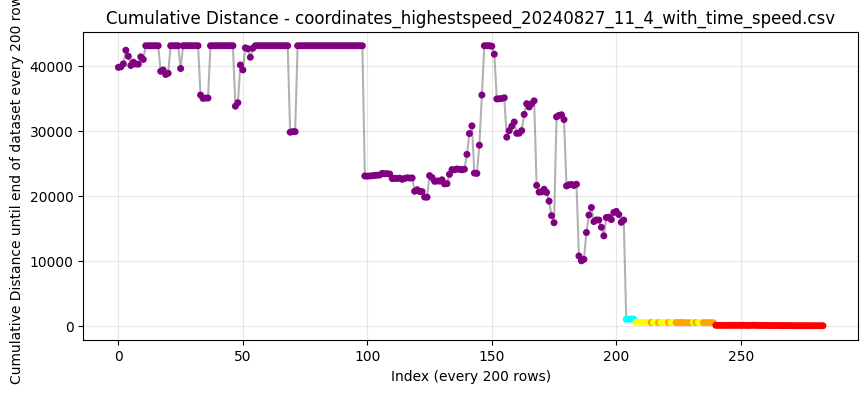

Analyzing: TERBINAFINE+\coordinates_highestspeed_20240827_9_5_with_time_speed.csv


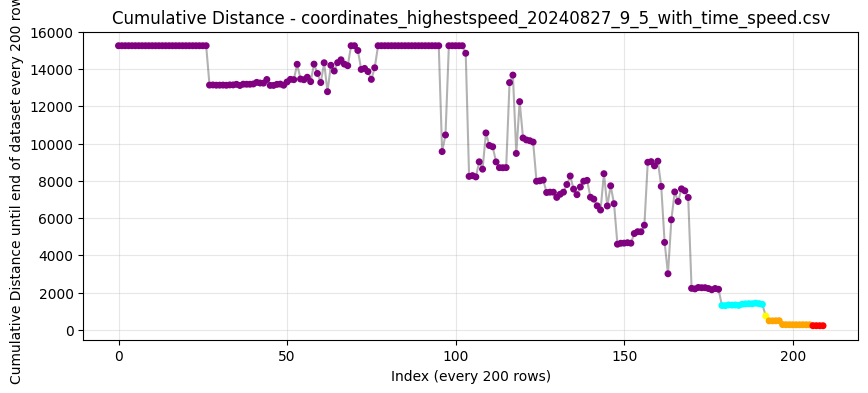

Analyzing: TERBINAFINE- (control)\coordinates_highestspeed_20250205_12_1_with_time_speed.csv


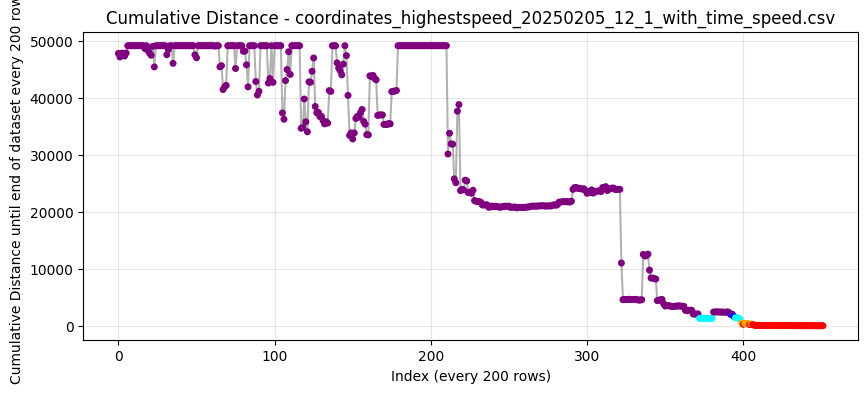

In [7]:
from utils.plot_utils.criterion import compute_total_smooth_cumulative_distance

# Relevant file examples to check
files_subset = [sorted(files)[3], sorted(files)[6], sorted(files)[69]]

for file in files_subset:
    file_path = os.path.join(preprocessed_folder, file)
    print(f"Analyzing: {file}")
    # Using parameters determined in speed.ipynb: freq1=200, freq2=200, smoothing_window=15
    cumulative_distances = compute_total_smooth_cumulative_distance(
        file_path, 
        freq1=200, 
        freq2=200, 
        smoothing_window=15
    )


The results found with this technique enables us to set a threshold on the cumulative distance to determine the end of life. We found that a threshold at a cumulative distance of less than 250 (corresponding to the red phase) is a good indicator of the end of life. We will keep it as our main criterion for determining the end of life in the next steps.

The full code is provided in the attached python file. 